# Бенчмарк производительности Dysmark

Этот ноутбук предназначен для измерения:
1. **Времени загрузки модели** (первый вызов).
2. **Времени инференса** (обработка аудио) при загруженной модели.
3. **Потребления оперативной памяти (RAM)** в пиковые моменты.

Каждый тест выполняется многократно.

## 1. Настройка окружения и конфигурация

In [1]:
import sys
import os
import time
import json
import csv
import gc
import traceback
from pathlib import Path
from collections import defaultdict
import statistics

# Библиотеки для мониторинга ресурсов
import psutil
import torch

# Визуализация
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Настройка стилей
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Путь к модулю
sys.path.insert(0, '../model')

# Конфигурация бенчмарка
NUM_ITERATIONS = 3  # Количество повторений для каждого файла
WARMUP_ITERATIONS = 1 # Количество "прогревающих" итераций перед замером

# Пути к данным
BASE_DIR = Path('..')
AUDIO_DIR = BASE_DIR / 'test_data' / 'performance'
TEXT_DIR = BASE_DIR / 'test_data' / 'performance'

# 
if not AUDIO_DIR.exists():
    print(f"Warning: Benchmark audio directory not found at {AUDIO_DIR}")
    print("Please place .wav files there or update the path.")

print(f"Configuration loaded. Iterations: {NUM_ITERATIONS}, Warmup: {WARMUP_ITERATIONS}")

Configuration loaded. Iterations: 3, Warmup: 1


## 2. Утилиты для замера ресурсов

In [2]:
class ResourceMonitor:
    """
    Класс для мониторинга использования памяти и времени.
    """
    def __init__(self):
        self.process = psutil.Process(os.getpid())
        self.start_mem = 0
        self.peak_mem = 0
        self.start_time = 0
        
    def start(self):
        gc.collect() # Сборка мусора перед стартом для чистоты замера
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
            
        self.start_mem = self.process.memory_info().rss / 1024 / 1024 # MB
        self.peak_mem = self.start_mem
        self.start_time = time.perf_counter()
        
    def update_peak(self):
        current_mem = self.process.memory_info().rss / 1024 / 1024
        if current_mem > self.peak_mem:
            self.peak_mem = current_mem
            
        if torch.cuda.is_available():
            cuda_mem = torch.cuda.max_memory_allocated() / 1024 / 1024
            # 
            
    def stop(self):
        end_time = time.perf_counter()
        self.update_peak()
        
        duration = end_time - self.start_time
        mem_delta = self.peak_mem - self.start_mem
        
        return {
            'duration_sec': duration,
            'peak_memory_mb': self.peak_mem,
            'memory_delta_mb': mem_delta
        }

def get_test_files():
    """
    Находит пары аудио/текст для тестирования.
    """
    pairs = []
    if not AUDIO_DIR.exists():
        return pairs
        
    audio_files = sorted(list(AUDIO_DIR.glob('*.wav')))
    
    for audio_path in audio_files:
        stem = audio_path.stem
        text_path = TEXT_DIR / f'{stem}.txt'
        
        if text_path.exists():
            with open(text_path, 'r', encoding='utf-8') as f:
                text = f.read().strip()
            pairs.append({
                'name': stem,
                'audio': str(audio_path),
                'text': text,
                'duration_sec': None # 
            })
        else:
            print(f"Warning: No text file for {audio_path.name}")
            
    return pairs

## 3. Тест 1: Холодная загрузка модели

Этот тест должен запускаться первым в свежем ядре Python. Он измеряет время скачивания (если нет кэша) и инициализации весов.

In [3]:
def benchmark_model_loading():
    print("Starting Model Loading Benchmark...")
    print("Note: This must be run in a fresh kernel session for accurate 'cold start' metrics.")
    
    monitor = ResourceMonitor()
    monitor.start()
    
    try:
        import dysmarkccls_clean as dysmark 
        
        processor, model = dysmark._load_model_cached()
                
    except Exception as e:
        print(f"Error during loading: {e}")
        traceback.print_exc()
        return None
        
    metrics = monitor.stop()
    
    print(f"Model loaded successfully.")
    print(f"Time: {metrics['duration_sec']:.2f} sec")
    print(f"Peak Memory: {metrics['peak_memory_mb']:.2f} MB")
    
    return metrics

# Запуск теста загрузки
# Для корректного теста перезапустите ядро (Kernel -> Restart) и запустите только эту ячейку и предыдущие конфиги.
loading_metrics = benchmark_model_loading()

Starting Model Loading Benchmark...
Note: This must be run in a fresh kernel session for accurate 'cold start' metrics.


Loading model (first use)...


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Model loaded successfully.
Time: 8.50 sec
Peak Memory: 902.25 MB


Model loaded.


## 4. Тест 2: Производительность инференса (Hot Model)

Замеряем время обработки аудио при уже загруженной модели. Выполняем N итераций для каждого файла.

In [4]:
import librosa

# Убедимся, что модель загружена
if 'dysmarkccls_clean' not in sys.modules:
    import dysmarkccls_clean as dysmark
    dysmark._load_model_cached()
else:
    import dysmarkccls_clean as dysmark

test_files = get_test_files()

if not test_files:
    print("No test files found! Please check paths.")
else:
    print(f"Found {len(test_files)} test files. Starting inference benchmark...")

inference_results = []

for file_info in test_files:
    print(f"\nProcessing: {file_info['name']}...", flush=True)
    
    # 1. Измеряем длительность аудио
    try:
        full_duration = librosa.get_duration(path=file_info['audio'])
        file_info['duration_sec'] = full_duration
    except Exception as e:
        print(f"  Error measuring duration: {e}")
        continue
        
    durations = []
    mem_deltas = []
    peak_mems = []
    
    # Прогрев (не входит в статистику)
    for _ in range(WARMUP_ITERATIONS):
        try:
            dysmark.get_markers(file_info['text'], file_info['audio'])
        except Exception as e:
            print(f"Warmup failed: {e}")
            break
            
    # Основные замеры
    for i in range(NUM_ITERATIONS):
        print(f"Iteration {i}", flush=True)
        monitor = ResourceMonitor()
        monitor.start()
        
        try:
            result = dysmark.get_markers(file_info['text'], file_info['audio'])
            _ = len(result['triples']) 
        except Exception as e:
            print(f"Iteration {i} failed: {e}")
            monitor.stop()
            continue
            
        metrics = monitor.stop()
        durations.append(metrics['duration_sec'])
        mem_deltas.append(metrics['memory_delta_mb'])
        peak_mems.append(metrics['peak_memory_mb'])
        monitor.update_peak()

    if durations:
        avg_time = statistics.mean(durations)
        std_time = statistics.stdev(durations) if len(durations) > 1 else 0
        avg_mem = statistics.mean(mem_deltas)
        max_peak_mem = max(peak_mems)
        
        # Расчет RTF (Real-Time Factor)
        # RTF = Время обработки / Длительность аудио
        # RTF < 1 означает, что обработка быстрее реального времени
        rtf = avg_time / full_duration if full_duration > 0 else float('inf')
        
        entry = {
            'file_name': file_info['name'],
            'audio_duration_sec': full_duration,
            'text_length': len(file_info['text']),
            'avg_duration_sec': avg_time,
            'std_duration_sec': std_time,
            'min_duration_sec': min(durations),
            'max_duration_sec': max(durations),
            'rtf': rtf,  # Ключевая метрика производительности
            'avg_mem_delta_mb': avg_mem,
            'max_peak_mem_mb': max_peak_mem,
            'iterations': len(durations)
        }
        inference_results.append(entry)
        print(f"  Done. Audio duration: {full_duration:.2f}s, Avg Processing Time: {avg_time:.3f}s, RTF: {rtf:.2f}", flush=True)
    else:
        print(f"  Failed all iterations for {file_info['name']}", flush=True)

print("\nInference benchmark completed.")

Found 4 test files. Starting inference benchmark...

Processing: Masha_p1...
Iteration 0
Iteration 1
Iteration 2
  Done. Audio duration: 171.71s, Avg Processing Time: 120.783s, RTF: 0.70

Processing: fruits...
Iteration 0
Iteration 1
Iteration 2
  Done. Audio duration: 2.64s, Avg Processing Time: 0.582s, RTF: 0.22

Processing: m1...
Iteration 0
Iteration 1
Iteration 2
  Done. Audio duration: 2.08s, Avg Processing Time: 0.476s, RTF: 0.23

Processing: our_village...
Iteration 0
Iteration 1
Iteration 2
  Done. Audio duration: 34.20s, Avg Processing Time: 10.962s, RTF: 0.32

Inference benchmark completed.


## 5. Анализ и визуализация результатов

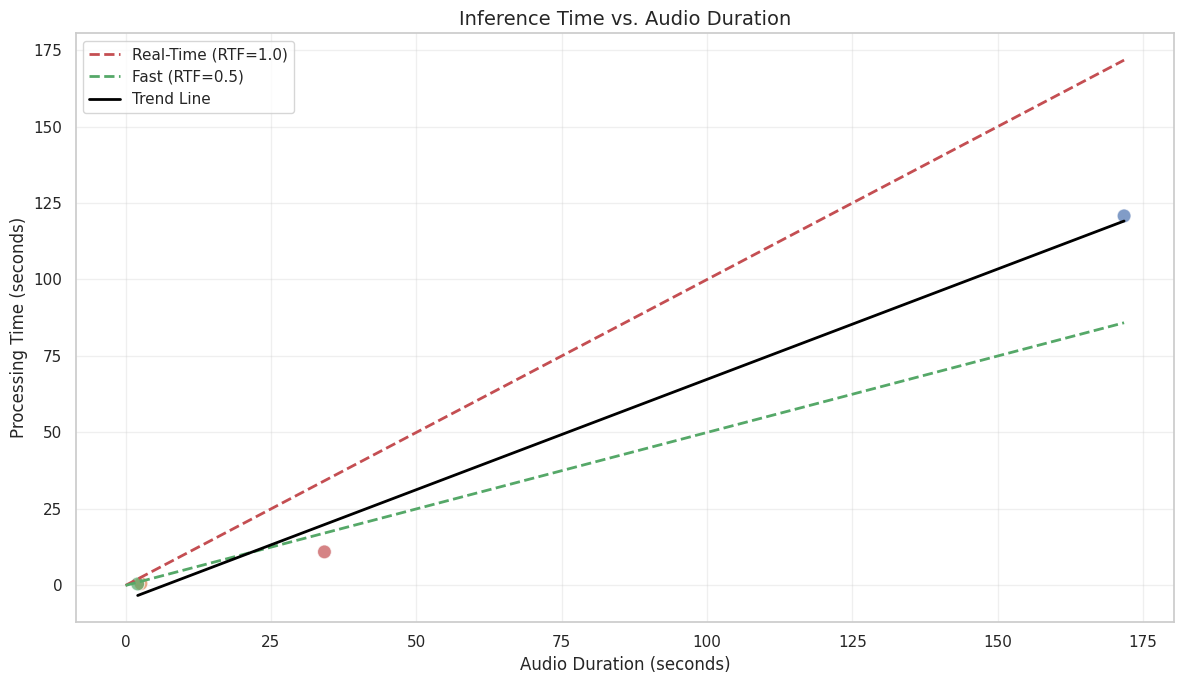

/tmp/ipykernel_763701/4157852596.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='file_name', y='rtf', palette='coolwarm')


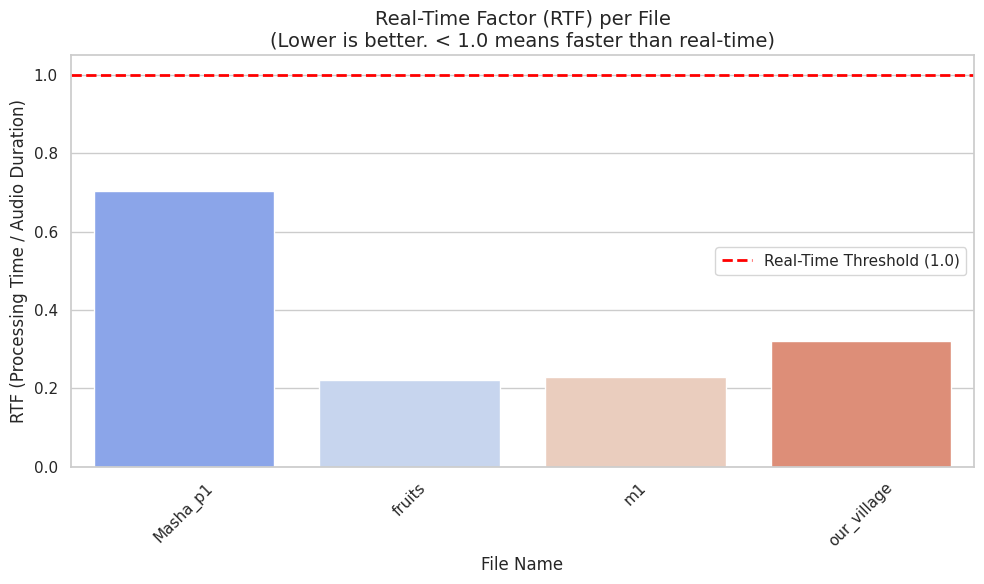

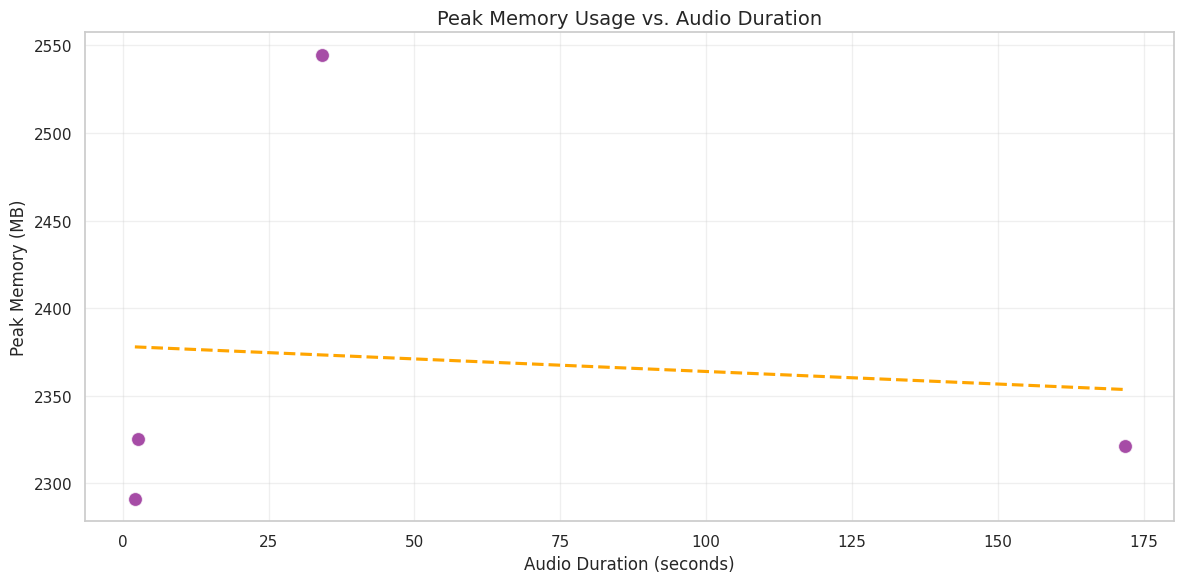


Summary Statistics (Sorted by Audio Duration):


,file_name,audio_duration_sec,avg_duration_sec,rtf,max_peak_mem_mb
2,m1,2.084014,0.476303,0.228551,2291.089844
1,fruits,2.640000,0.582478,0.220636,2325.511719
3,our_village,34.200000,10.962198,0.320532,2544.699219
0,Masha_p1,171.712000,120.782727,0.703403,2321.312500



Overall Average RTF: 0.368 (FASTER than real-time)
Overall Max Peak Memory: 2544.7 MB
Model Loading Time (Cold Start): 8.50 sec


In [7]:
if inference_results:
    df = pd.DataFrame(inference_results)
    
    # Сортировка для графика по длительности
    df_sorted = df.sort_values('audio_duration_sec')

    # --- График 1: Зависимость времени обработки от длины аудио (Скаттерплот + Регрессия) ---
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=df, x='audio_duration_sec', y='avg_duration_sec', s=100, hue='file_name', legend=False, alpha=0.7)
    
    # Линия производительности RTF=1
    max_dur = df['audio_duration_sec'].max()
    plt.plot([0, max_dur], [0, max_dur], 'r--', label='Real-Time (RTF=1.0)', linewidth=2)
    # Линия RTF=0.5 (в 2 раза быстрее реальности)
    plt.plot([0, max_dur], [0, max_dur/2], 'g--', label='Fast (RTF=0.5)', linewidth=2)
    
    # Линия регрессии по реальным данным
    sns.regplot(data=df, x='audio_duration_sec', y='avg_duration_sec', scatter=False, color='black', line_kws={'linestyle':'-', 'linewidth':2}, label='Trend Line', ci=None)
    
    plt.title('Inference Time vs. Audio Duration', fontsize=14)
    plt.xlabel('Audio Duration (seconds)', fontsize=12)
    plt.ylabel('Processing Time (seconds)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- График 2: Распределение RTF (Real-Time Factor) ---
    # Показывает, во сколько раз обработка медленнее/быстрее аудио
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='file_name', y='rtf', palette='coolwarm')
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Real-Time Threshold (1.0)')
    plt.title('Real-Time Factor (RTF) per File\n(Lower is better. < 1.0 means faster than real-time)', fontsize=14)
    plt.xlabel('File Name')
    plt.ylabel('RTF (Processing Time / Audio Duration)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- График 3: Потребление памяти от длины аудио ---
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x='audio_duration_sec', y='max_peak_mem_mb', s=100, color='purple', alpha=0.7)
    sns.regplot(data=df, x='audio_duration_sec', y='max_peak_mem_mb', scatter=False, color='orange', line_kws={'linestyle':'--'}, ci=None)
    plt.title('Peak Memory Usage vs. Audio Duration', fontsize=14)
    plt.xlabel('Audio Duration (seconds)')
    plt.ylabel('Peak Memory (MB)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Сводная таблица ---
    print("\nSummary Statistics (Sorted by Audio Duration):")
    display(df[['file_name', 'audio_duration_sec', 'avg_duration_sec', 'rtf', 'max_peak_mem_mb']].sort_values('audio_duration_sec'))
    
    # Общие метрики
    avg_rtf = df['rtf'].mean()
    status = "FASTER than real-time" if avg_rtf < 1.0 else "SLOWER than real-time"
    
    print(f"\nOverall Average RTF: {avg_rtf:.3f} ({status})")
    print(f"Overall Max Peak Memory: {df['max_peak_mem_mb'].max():.1f} MB")
    
    if loading_metrics:
        print(f"Model Loading Time (Cold Start): {loading_metrics['duration_sec']:.2f} sec")

else:
    print("No data to visualize. Check if tests ran successfully.")

## 6. Экспорт результатов

Сохраняем сырые данные в CSV для отчета.

In [ ]:
if inference_results:
    output_csv = 'benchmark_results.csv'
    df.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")
    
    # метаданные загрузки модели в отдельный JSON если они есть
    if loading_metrics:
        meta_file = 'benchmark_model_load.json'
        with open(meta_file, 'w') as f:
            json.dump(loading_metrics, f, indent=2)
        print(f"Model load metrics saved to {meta_file}")
else:
    print("No results to save.")